# 예상 전환률 산점도 찍는 함수

n개의 항목에 대해서 특정 범주에 속하는 수가 랜덤일 때 범주 출현률(x축)에 대해 전환률(y축)을 찍어 봄.

In [1]:
# n개의 항목이 있을 때, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수. 
# n은 전체 항목 수, k는 특정 범주에 속하는 항목 수를 나타낸다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다.

import pandas as pd
import matplotlib.pyplot as plt

# n개의 항목이 있을 때, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수. n은 전체 항목 수, k는 특정 범주에 속하는 항목 수를 나타낸다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다.
# 최저 전환 수는 한쪽이 0이면 0, 둘 다 있으면 최소 1이다. 최고 전환 수는 두 범주를 최대한 번갈아 배열할 때의 최대 전환 수로 계산한다. 기대 전환 수는 고정된 k개를 무작위 배열한다고 할 때의 평균 전환 수로 계산한다. 결과는 pandas DataFrame으로 반환된다.
def transition_possibility_table(n):
    rows = []

    for k in range(n + 1):
        other = n - k
        p = k / n

        # 가능한 인접쌍 수
        pair_count = n - 1

        # 최저 전환 수: 한쪽이 0이면 0, 둘 다 있으면 최소 1
        if k == 0 or k == n:
            min_transitions = 0
        else:
            min_transitions = 1

        # 최고 전환 수: 두 범주를 최대한 번갈아 배열
        max_transitions = min(pair_count, 2 * min(k, other)) # 최대 전환 수는 전체 인접쌍 수와 2 * min(k, other) 중 작은 값이다. 2 * min(k, other)는 k개와 other개가 번갈아 배열될 때의 최대 전환 수를 나타낸다.

        # 기대 전환 수: 고정된 k개를 무작위 배열한다고 할 때
        expected_transitions = 2 * k * other / n

        rows.append({
            "n": n,
            "k": k,
            "출현률": p,
            "최저전환수": min_transitions,
            "최고전환수": max_transitions,
            "기대전환수": expected_transitions,
            "최저전환률": min_transitions / pair_count if pair_count > 0 else 0,
            "최고전환률": max_transitions / pair_count if pair_count > 0 else 0,
            "기대전환률": expected_transitions / pair_count if pair_count > 0 else 0,
        })

    return pd.DataFrame(rows)

# 전환 가능성 테이블 생성 및 시각화
def plot_transition_possibility(n=100):
    df = transition_possibility_table(n)

    plt.figure(figsize=(10, 6)) # 그래프 크기 조절

    plt.plot(df["출현률"], df["최저전환률"], label="Minimum transition rate") # 출현률에 따른 최저 전환률을 선 그래프로 그린다. x축은 출현률, y축은 최저 전환률이다. label은 범례에 표시될 이름이다.
    plt.plot(df["출현률"], df["최고전환률"], label="Maximum transition rate") # 출현률에 따른 최고 전환률을 선 그래프로 그린다. x축은 출현률, y축은 최고 전환률이다. label은 범례에 표시될 이름이다.
    plt.plot(df["출현률"], df["기대전환률"], label="Expected transition rate") # 출현률에 따른 기대 전환률을 선 그래프로 그린다. x축은 출현률, y축은 기대 전환률이다. label은 범례에 표시될 이름이다.

    plt.xlabel("Occurrence rate of target tense") # x축 레이블 설정
    plt.ylabel("Transition rate") # y축 레이블 설정
    plt.title(f"Possible transition rates by occurrence rate (n={n})") # 그래프 제목 설정
    plt.legend() # 범례 표시
    plt.grid(True) # 격자선 표시
    plt.show()

    return df



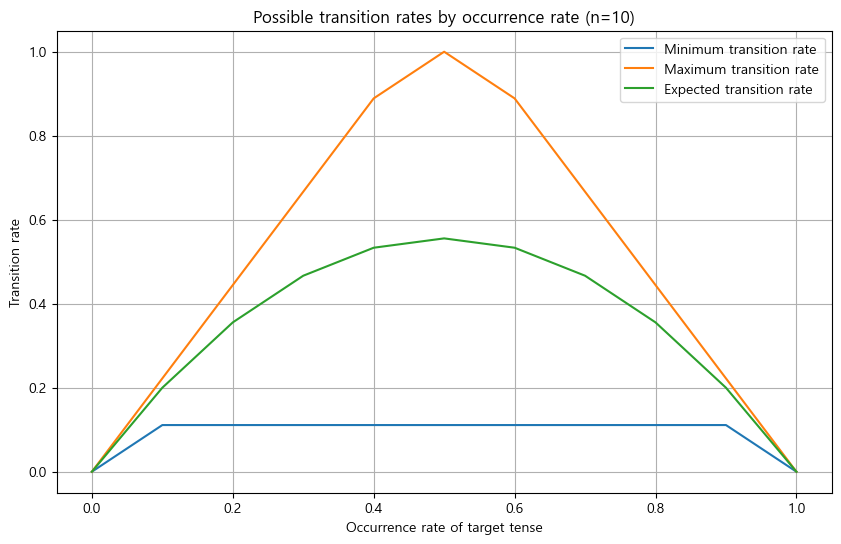

In [66]:
df_possible = plot_transition_possibility(n=10)


In [ ]:
# n_min부터 n_max의 전체 항목수에 대해서, 
# 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수. n은 전체 항목 수, k는 특정 범주에 속하는 항목 수를 나타낸다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다.
# make_transition_space(n_min=20, n_max=100) 함수는 n_min부터 n_max까지의 전체 항목 수에 대해서, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수이다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다. 결과는 pandas DataFrame으로 반환된다.
import pandas as pd
import matplotlib.pyplot as plt

 
def make_transition_space(n_min=20, n_max=100):

    rows = []

    for n in range(n_min, n_max + 1):

        pair_count = n - 1

        for k in range(n + 1):

            p = k / n
            other = n - k

            # 최소 전환수
            if k == 0 or k == n:
                min_t = 0
            else:
                min_t = 1

            # 최대 전환수
            max_t = min(pair_count, 2 * min(k, other))

            # 기대 전환수
            exp_t = 2 * k * other / n

            rows.append({
                "n": n,
                "k": k,
                "p": p,

                "min_rate": min_t / pair_count if pair_count else 0,
                "max_rate": max_t / pair_count if pair_count else 0,
                "exp_rate": exp_t / pair_count if pair_count else 0,
            })

    return pd.DataFrame(rows)

# 전환 가능성 공간 시각화
def plot_transition_space(n_min=20, n_max=100):

    df = make_transition_space(n_min, n_max)

    plt.figure(figsize=(12, 8))

    # 최소
    plt.scatter(
        df["p"],
        df["min_rate"],
        s=8,
        alpha=0.25,
        label="Minimum transition rate"
    )

    # 최대
    plt.scatter(
        df["p"],
        df["max_rate"],
        s=8,
        alpha=0.25,
        label="Maximum transition rate"
    )

    # 기대
    plt.scatter(
        df["p"], # 출현률 p, x축 값: k/n으로 계산된 값
        df["exp_rate"],
        s=8,
        alpha=0.4,
        label="Expected transition rate"
    )

    plt.xlabel("Occurrence rate p")
    plt.ylabel("Transition rate")

    plt.title(
        f"Transition-rate possibility space (n={n_min}~{n_max})"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

    return df

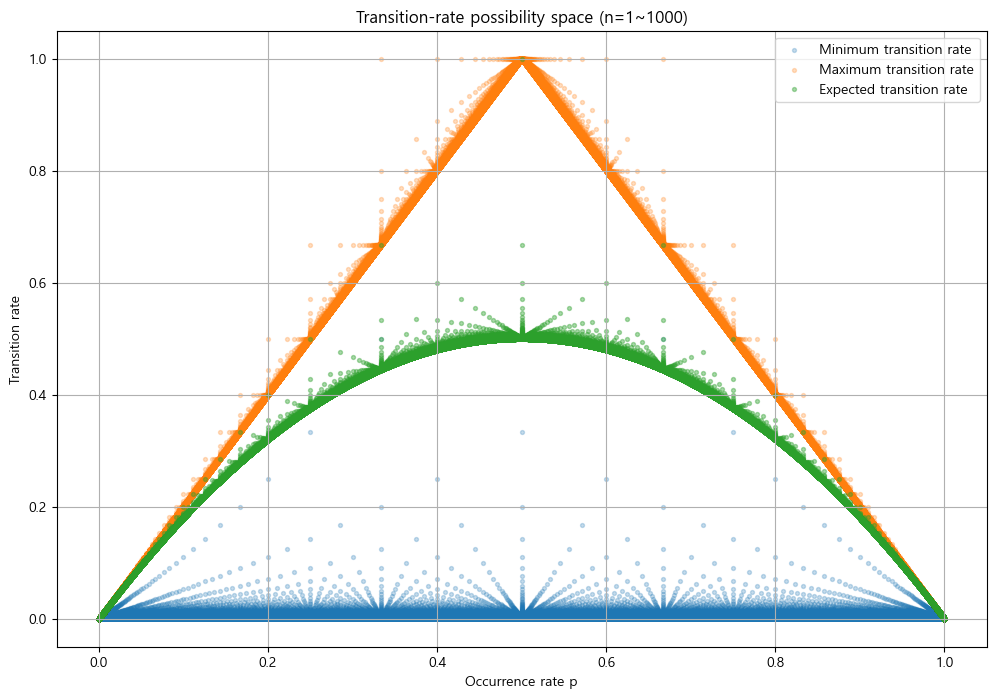

In [78]:
df_space = plot_transition_space(1, 1000)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시퀀스에서 전환률 계산하는 함수. seq는 0과 1로 이루어진 시퀀스라고 가정한다. 전환률은 인접한 항목이 서로 다른 경우의 비율로 계산한다. 예를 들어, [0, 0, 1, 1, 0]이라는 시퀀스가 있으면, 인접한 항목이 서로 다른 경우는 (0, 1)과 (1, 0) 두 번 발생하므로 전환 수는 2이다. 전체 인접쌍 수는 시퀀스 길이 - 1이므로 이 경우에는 4이다. 따라서 전환률은 2/4 = 0.5가 된다.
def transition_rate(seq):
    seq = np.array(seq)
    return np.mean(seq[:-1] != seq[1:])

# n개의 항목이 있을 때, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수. n은 전체 항목 수, k는 특정 범주에 속하는 항목 수를 나타낸다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다.
def simulate_transition_distribution(
    n,
    k,
    n_sim=1000
):

    base = np.array([1]*k + [0]*(n-k))

    rates = []

    for _ in range(n_sim):

        shuffled = np.random.permutation(base)

        r = transition_rate(shuffled)

        rates.append(r)

    return np.array(rates)

# n_min부터 n_max의 전체 항목수에 대해서,
# 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수. n은 전체 항목 수, k는 특정 범주에 속하는 항목 수를 나타낸다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다.
# make_transition_space(n_min=20, n_max=100) 함수는 n_min부터 n_max까지의 전체 항목 수에 대해서, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수이다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다. 결과는 pandas DataFrame으로 반환된다.
# build_quantile_space(n_min=20, n_max=100, n_sim=1000) 함수는 n_min부터 n_max까지의 전체 항목 수에 대해서, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수이다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다. 각 (n, k) 조합에 대해서 simulate_transition_distribution 함수를 사용해서 n_sim번의 시뮬레이션을 수행하여 전환률 분포를 얻는다. 그리고 그 분포에서 최소값, 25% 분위수, 중앙값, 75% 분위수, 최대값, 평균값을 계산하여 데이터프레임으로 반환한다.

def build_quantile_space(
    n_min=20,
    n_max=100,
    n_sim=1000
):

    rows = []

    for n in range(n_min, n_max+1):

        for k in range(n+1):

            p = k / n

            rates = simulate_transition_distribution(
                n,
                k,
                n_sim=n_sim
            )

            rows.append({

                "n": n,
                "p": p,

                "min": rates.min(),
                "q25": np.quantile(rates, 0.25),
                "median": np.quantile(rates, 0.50),
                "q75": np.quantile(rates, 0.75),
                "max": rates.max(),
                "mean": rates.mean(),
            })

    return pd.DataFrame(rows)


def plot_quantile_space(df):

    plt.figure(figsize=(12, 8))

    plt.scatter(df["p"], df["min"],
                s=5, alpha=0.2, label="Min")

    plt.scatter(df["p"], df["q25"],
                s=5, alpha=0.3, label="Q25")

    plt.scatter(df["p"], df["median"],
                s=5, alpha=0.4, label="Median")

    plt.scatter(df["p"], df["q75"],
                s=5, alpha=0.3, label="Q75")

    plt.scatter(df["p"], df["max"],
                s=5, alpha=0.2, label="Max")

    plt.scatter(df["p"], df["mean"],
                s=8, alpha=0.7, label="Mean")

    plt.xlabel("Occurrence rate p")
    plt.ylabel("Transition rate")

    plt.title("Transition-rate distribution space")

    plt.legend()
    plt.grid(True)

    plt.show()

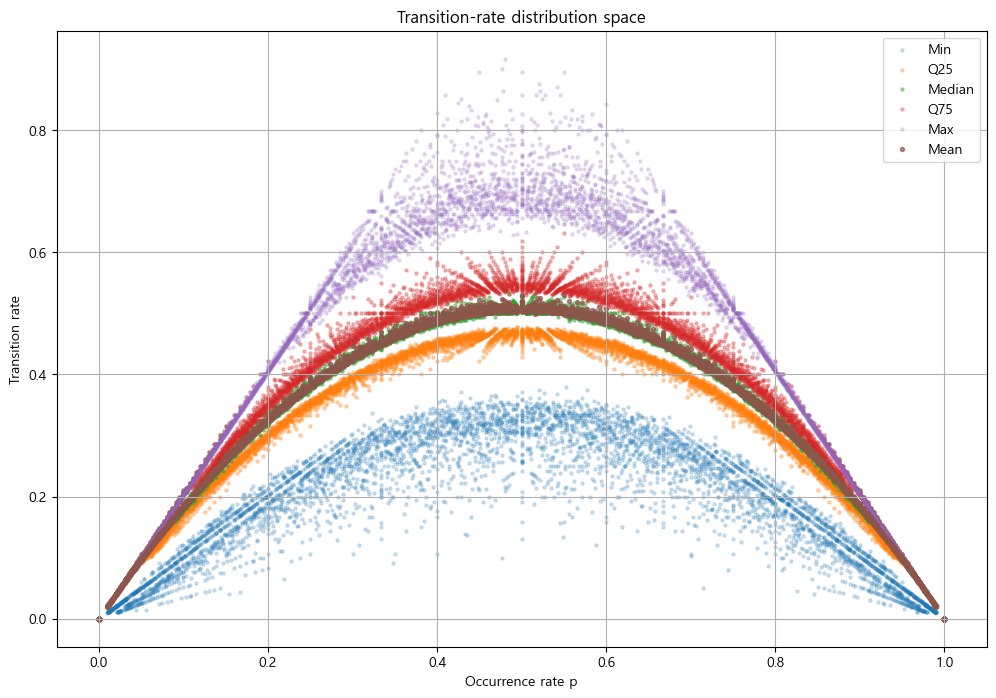

In [73]:
df_q = build_quantile_space(
    n_min=20,
    n_max=100,
    n_sim=1000
)

plot_quantile_space(df_q)

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 전환률 계산
# -----------------------------
def transition_rate(seq):

    seq = np.array(seq)

    return np.mean(seq[:-1] != seq[1:])


# -----------------------------
# 전체 분포 생성, 시뮬레이션과 이론값을 함께 계산, 데이터프레임으로 반환
# -----------------------------
# build_distribution_space(n=50, n_sim=1000) 함수는 n개의 항목이 있을 때, 특정 범주에 속하는 수 k에 따른 최저, 최고, 기대 전환 수와 전환률을 계산하는 함수이다. n은 전체 항목 수, k는 특정 범주에 속하는 항목 수를 나타낸다. 이 함수는 k가 0부터 n까지 변화할 때의 전환 가능성 테이블을 생성한다. 각 (n, k) 조합에 대해서 simulate_transition_distribution 함수를 사용해서 n_sim번의 시뮬레이션을 수행하여 전환률 분포를 얻는다. 그리고 그 분포에서 최소값, 25% 분위수, 중앙값, 75% 분위수, 최대값, 평균값을 계산하여 데이터프레임으로 반환한다.
def build_distribution_space(
    n=50,
    n_sim=1000
):

    rows = []

    pair_count = n - 1

    for k in range(n + 1):

        p = k / n

        base = np.array([1]*k + [0]*(n-k))

        rates = []

        for _ in range(n_sim):

            shuffled = np.random.permutation(base)

            r = transition_rate(shuffled)

            rates.append(r)

            # 시뮬레이션 점 저장
            rows.append({
                "p": p,
                "rate": r,
                "type": "simulation"
            })

        rates = np.array(rates)

        # -----------------------------
        # 이론값 계산
        # -----------------------------

        # 최소
        if k == 0 or k == n:
            min_rate = 0
        else:
            min_rate = 1 / pair_count

        # 최대
        max_rate = min(
            pair_count,
            2 * min(k, n-k)
        ) / pair_count

        # 기대
        expected_rate = (
            2 * k * (n-k) / n
        ) / pair_count

        # 분위수
        q25 = np.quantile(rates, 0.25)
        median = np.quantile(rates, 0.50)
        q75 = np.quantile(rates, 0.75)

        # 선 데이터 저장
        rows.extend([

            {"p": p, "rate": min_rate, "type": "min"},
            {"p": p, "rate": q25, "type": "q25"},
            {"p": p, "rate": median, "type": "median"},
            {"p": p, "rate": q75, "type": "q75"},
            {"p": p, "rate": expected_rate, "type": "expected"},
            {"p": p, "rate": max_rate, "type": "max"},

        ])

    return pd.DataFrame(rows)


# -----------------------------
# Plot: 시뮬레이션 점과 분위선들을 함께 그리는 함수
# -----------------------------
def plot_distribution_space(
    n=50,
    n_sim=1000
):

    df = build_distribution_space(
        n=n,
        n_sim=n_sim
    )

    plt.figure(figsize=(13, 8)) # plt: matplotlib.pyplot의 약자이다. plt.figure()는 새로운 그림을 생성하는 함수이고, figsize=(13, 8)은 그림의 크기를 가로 13인치, 세로 8인치로 설정한다. 그래프 크기 조절 (필요에 따라 조정 가능, 일반적으로 (8,6)에서 (12,8) 사이에서 조절한다)

    # -----------------------------
    # 시뮬레이션 점
    # -----------------------------
    sim_df = df[df["type"] == "simulation"]

    plt.scatter( #scatter 함수는 산점도를 그리는 함수이다. 시뮬레이션에서 나온 출현률 값과 전환률 값을 x축과 y축으로 사용하여 점을 그린다. s=6은 점의 크기를 6으로 설정하는 것이다. alpha=0.15는 점의 투명도를 0.15로 설정하는 것이다. label="Simulations"은 범례에 표시될 이름을 "Simulations"으로 설정하는 것이다.
        sim_df["p"], # 시뮬레이션에서 나온 출현률 값, x축 값
        sim_df["rate"], # 시뮬레이션에서 나온 전환률 값
        s=6, # 점 크기
        alpha=0.15, # 점 투명도
        label="Simulations", # 범례에 표시될 이름
        marker='o', # 점 모양을 원으로 설정, marker 스타일은 'o'로 설정하여 원형 점을 그린다. 필요에 따라 다른 모양으로 변경할 수 있다 (예: 's'는 사각형, '^'는 삼각형 등).
        edgecolors='none', # 점 테두리 색깔을 없애서 더 깔끔하게 보이도록 설정
        rasterized=True # 그래픽이 복잡할 때 성능 향상을 위해 점을 래스터 이미지로 처리하도록 설정, 특히 점이 많을 때 유용하다. 래스터화는 벡터 그래픽 대신 픽셀 기반으로 점을 그리는 방식으로, 많은 점을 그릴 때 렌더링 속도를 개선할 수 있다.
    )

    # -----------------------------
    # 분위선들
    # -----------------------------
    line_styles = {
        "min": "--",
        "q25": ":",
        "median": "-.",
        "q75": ":",
        "expected": "-",
        "max": "--",
    }

    for t in ["min", "q25", "median", "q75", "expected", "max"]:

        sub = df[df["type"] == t]

        plt.plot(
            sub["p"],
            sub["rate"],
            linestyle=line_styles[t], # 선 스타일 설정
            linewidth=2,
            label=t
        )

    plt.xlabel("Occurrence rate p")
    plt.ylabel("Transition rate")

    plt.title(
        f"Transition-rate distribution space (n={n})"
    )

    plt.legend()
    plt.grid(True)

    plt.show()

    return df

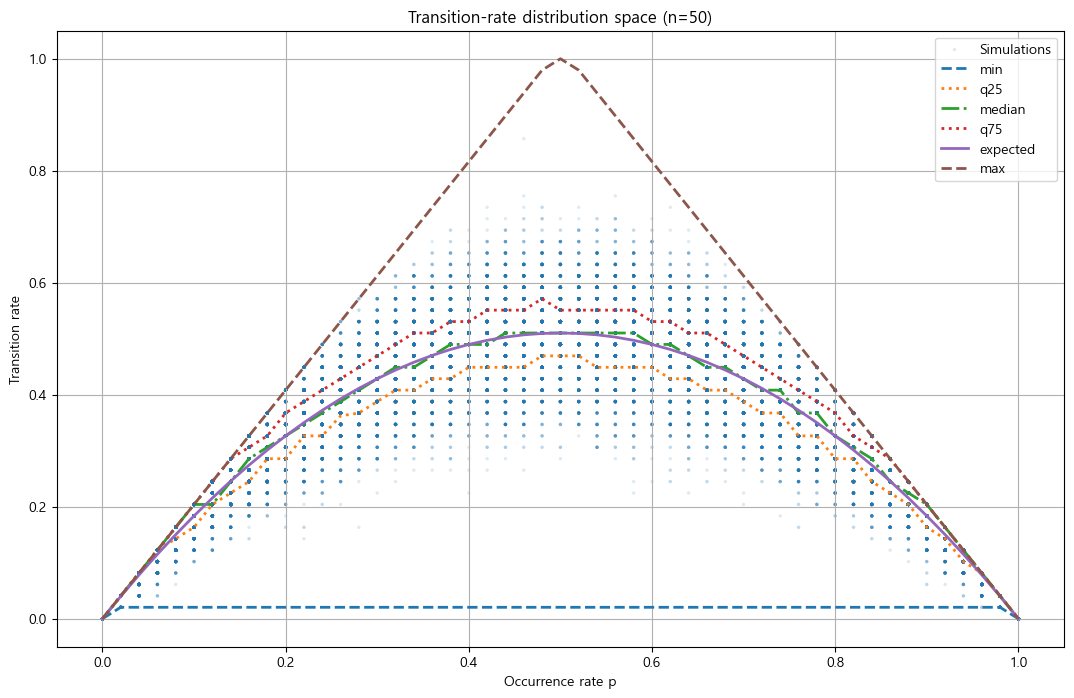

In [81]:
df_space = plot_distribution_space(
    n=50,
    n_sim=1000
)

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 전환률 계산
# -----------------------------
def transition_rate(seq):

    seq = np.array(seq)

    return np.mean(seq[:-1] != seq[1:])


# -----------------------------
# 하나의 n에 대한 데이터 생성
# -----------------------------
def build_distribution_space(
    n=50,
    n_sim=1000
):

    rows = []

    pair_count = n - 1

    for k in range(n + 1):

        p = k / n

        base = np.array([1]*k + [0]*(n-k))

        rates = []

        for _ in range(n_sim):

            shuffled = np.random.permutation(base)

            r = transition_rate(shuffled)

            rates.append(r)

        rates = np.array(rates)

        # 이론값들
        if k == 0 or k == n:
            min_rate = 0
        else:
            min_rate = 1 / pair_count

        max_rate = min(
            pair_count,
            2 * min(k, n-k)
        ) / pair_count

        expected_rate = (
            2 * k * (n-k) / n
        ) / pair_count

        rows.append({

            "n": n,
            "p": p,

            "min": min_rate,
            "q25": np.quantile(rates, 0.25),
            "median": np.quantile(rates, 0.50),
            "q75": np.quantile(rates, 0.75),
            "expected": expected_rate,
            "max": max_rate,

            "rates": rates
        })

    return rows


# -----------------------------
# 여러 n을 하나의 그래프에
# -----------------------------
def plot_multiple_n_spaces(
    n_list=[20, 40, 60, 80, 100],
    n_sim=1000
):

    plt.figure(figsize=(14, 10))

    colors = plt.cm.tab10.colors

    for idx, n in enumerate(n_list):

        color = colors[idx]

        rows = build_distribution_space(
            n=n,
            n_sim=n_sim
        )

        # -----------------------------
        # 시뮬레이션 점
        # -----------------------------
        for row in rows:

            p = row["p"]

            rates = row["rates"]

            # jitter
            x = (
                np.full(len(rates), p)
                + np.random.normal(0, 0.0015, len(rates))
            )

            y = (
                rates
                + np.random.normal(0, 0.0015, len(rates))
            )

            plt.scatter(
                x,
                y,
                s=6,
                alpha=0.03,
                color=color,
                edgecolors='none',
                rasterized=True
            )

        # -----------------------------
        # 선들
        # -----------------------------
        p_vals = [r["p"] for r in rows]

        for key, style, width in [

            ("min", "--", 1),
            ("q25", ":", 1.5),
            ("median", "-.", 1.5),
            ("q75", ":", 1.5),
            ("expected", "-", 2.5),
            ("max", "--", 1),

        ]:

            y_vals = [r[key] for r in rows]

            plt.plot(
                p_vals,
                y_vals,
                linestyle=style,
                linewidth=width,
                color=color,
                label=f"{key} (n={n})"
                if key == "expected"
                else None
            )

    plt.xlabel("Occurrence rate p")

    plt.ylabel("Transition rate")

    plt.title(
        "Transition-rate distribution spaces across different n"
    )

    plt.grid(True)

    plt.legend()

    plt.show()

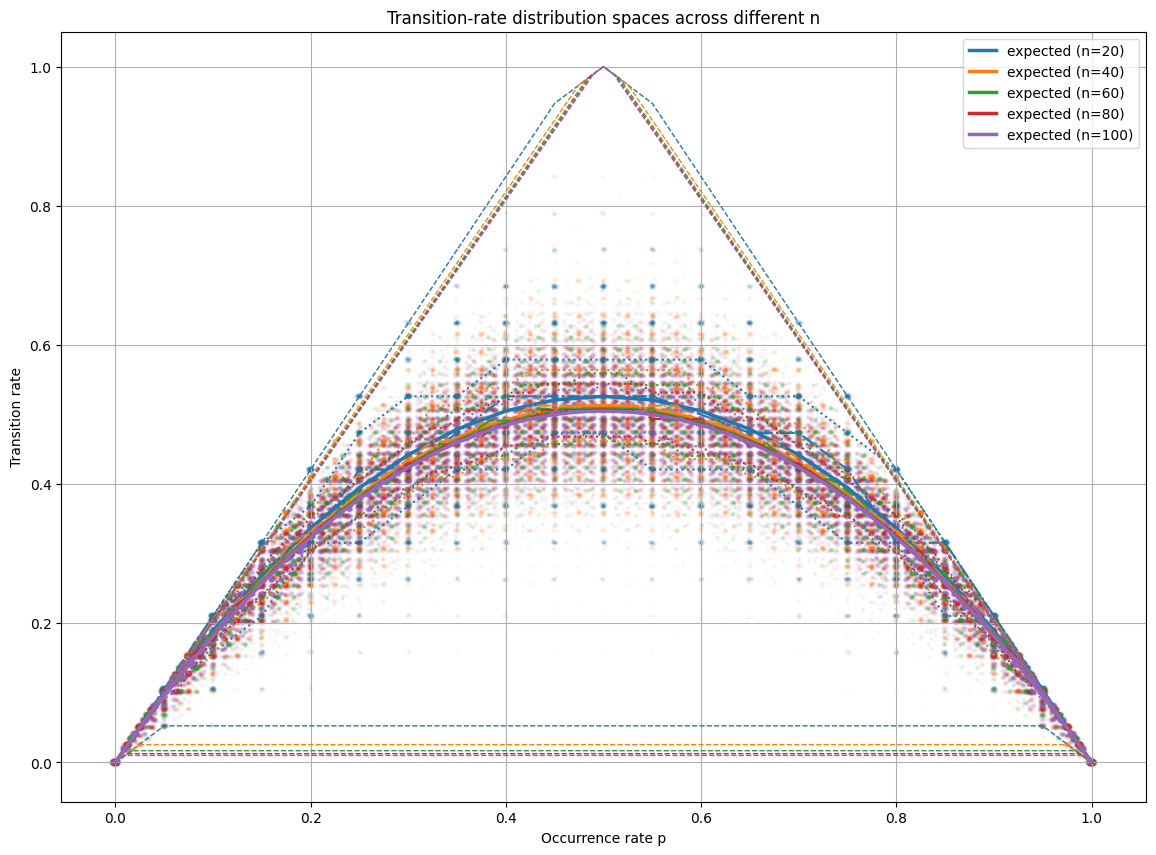

In [ ]:
plot_multiple_n_spaces(
    n_list=[20, 40, 60, 80, 100],
    n_sim=1000
)